In [127]:
import sys
print(sys.executable)

c:\Users\yiho1\8ssible-Healing-Seoul-Analysis\.venv\Scripts\python.exe


In [128]:
import re
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

sns.set_theme(style="whitegrid")
plt.rcParams["font.family"] = "Malgun Gothic"
plt.rcParams["axes.unicode_minus"] = False

In [129]:
from sqlalchemy import create_engine
import pandas as pd

user = "team8_admin"
password = "admin1!"
host = "34.50.4.76"
port = 3306
database = "team8_11"

engine = create_engine(
    f"mysql+pymysql://{user}:{password}@{host}:{port}/{database}"
)

conn = engine.connect()
print("연결 성공!")

연결 성공!


In [130]:
noise = pd.read_sql("SELECT * FROM noise_integrated", engine)
noise_com = pd.read_sql("SELECT * FROM noise_complaint", engine)
vibration = pd.read_sql("SELECT * FROM vibration_integrated", engine)

crime = pd.read_sql("SELECT * FROM 5_crimes", engine)
dispatch = pd.read_sql("SELECT * FROM dispatch_integrated", engine)

population = pd.read_sql(
    """
    SELECT 자치구,
           `2022_행정구역(A)_인구 (명)`,
           `2023_행정구역(A)_인구 (명)`,
           `2024_행정구역(A)_인구 (명)`
    FROM garbage_collection_status
    """,
    engine
)


In [131]:
noise.columns, noise_com.columns, vibration.columns, population.columns

(Index(['gu_code', '자치구', '지역', '2201', '2202', '2203', '2204', '2205', '2206',
        '2207', '2208', '2209', '2210', '2211', '2212', '2301', '2302', '2303',
        '2304', '2305', '2306', '2307', '2308', '2309', '2310', '2311', '2312',
        '2401', '2402', '2403', '2404', '2405', '2406', '2407', '2408', '2409',
        '2410', '2411', '2412'],
       dtype='str'),
 Index(['자치구별(2)', '2022', '2022_1', '2023', '2023_1', '2024', '2024_1'], dtype='str'),
 Index(['gu_code', '자치구', '2201_v_x', '2201_v_y', '2201_v_z', '2202_v_x',
        '2202_v_y', '2202_v_z', '2203_v_x', '2203_v_y',
        ...
        '2409_v_z', '2410_v_x', '2410_v_y', '2410_v_z', '2411_v_x', '2411_v_y',
        '2411_v_z', '2412_v_x', '2412_v_y', '2412_v_z'],
       dtype='str', length=110),
 Index(['자치구', '2022_행정구역(A)_인구 (명)', '2023_행정구역(A)_인구 (명)',
        '2024_행정구역(A)_인구 (명)'],
       dtype='str'))

In [132]:
noise_com.head()

,자치구별(2),2022,2022_1,2023,2023_1,2024,2024_1
0,소계,83743,74257,75931,63452,79451,59263
1,종로구,2800,2480,2512,2200,2255,2057
2,중구,2820,2820,1678,1223,1360,1180
3,용산구,3549,3080,3614,3175,3053,2673
4,성동구,2916,2631,2691,2574,2589,2477


In [133]:
population.head()

,자치구,2022_행정구역(A)_인구 (명),2023_행정구역(A)_인구 (명),2024_행정구역(A)_인구 (명)
0,종로구,152211,150453,149608
1,중구,130785,131793,131214
2,용산구,233284,227106,217194
3,성동구,288234,284766,281289
4,광진구,351252,351180,348652


## 민원점수

- 소음진동 민원 데이터와 인구 데이터를 자치구 기준으로 결합
- 단순 민원 건수는 인구가 많은 자치구에 불리하므로, 인구 1만 명당 민원 건수로 보정
- 이후 연도별 1~8점 범위의 민원 스트레스 점수를 만듬

In [134]:
noise_com = noise_com.rename(columns={
    "자치구별(2)": "자치구",
    "2022": "환경관련민원_2022",
    "2022_1": "소음진동민원_2022",
    "2023": "환경관련민원_2023",
    "2023_1": "소음진동민원_2023",
    "2024": "환경관련민원_2024",
    "2024_1": "소음진동민원_2024",
})

population = population.rename(columns={
    "2022_행정구역(A)_인구 (명)": "인구_2022",
    "2023_행정구역(A)_인구 (명)": "인구_2023",
    "2024_행정구역(A)_인구 (명)": "인구_2024",
})


In [135]:
# 구별끼리의 비교라 소계는 제외
noise_com = noise_com[noise_com["자치구"] != "소계"].copy()
population = population[population["자치구"] != "소계"].copy()

In [136]:
noise_com["자치구"].nunique()

25

In [137]:
population["자치구"].nunique()

25

In [183]:
# 자치구별 민원 데이터와 인구 데이터를 합침
complaint_pop = noise_com[
    ["자치구", "소음진동민원_2022", "소음진동민원_2023", "소음진동민원_2024"]
].merge(
    population[["자치구", "인구_2022", "인구_2023", "인구_2024"]],
    on="자치구",
    how="left"
)

complaint_pop.head()

,자치구,소음진동민원_2022,소음진동민원_2023,소음진동민원_2024,인구_2022,인구_2023,인구_2024
0,종로구,2480,2200,2057,152211,150453,149608
1,중구,2820,1223,1180,130785,131793,131214
2,용산구,3080,3175,2673,233284,227106,217194
3,성동구,2631,2574,2477,288234,284766,281289
4,광진구,1892,1374,1329,351252,351180,348652


In [139]:
complaint_pop.isnull().sum()


자치구            0
소음진동민원_2022    0
소음진동민원_2023    0
소음진동민원_2024    0
인구_2022        0
인구_2023        0
인구_2024        0
dtype: int64

In [ ]:
# 인구만명당 소음민원
complaint_pop["만명당소음민원_2022"] = complaint_pop["소음진동민원_2022"] / complaint_pop["인구_2022"] * 10000
complaint_pop["만명당소음민원_2023"] = complaint_pop["소음진동민원_2023"] / complaint_pop["인구_2023"] * 10000
complaint_pop["만명당소음민원_2024"] = complaint_pop["소음진동민원_2024"] / complaint_pop["인구_2024"] * 10000

complaint_pop

,자치구,소음진동민원_2022,소음진동민원_2023,소음진동민원_2024,인구_2022,인구_2023,인구_2024,만명당소음민원_2022,만명당소음민원_2023,만명당소음민원_2024
0,종로구,2480,2200,2057,152211,150453,149608,162.931720,146.225067,137.492647
1,중구,2820,1223,1180,130785,131793,131214,215.621057,92.797038,89.929428
2,용산구,3080,3175,2673,233284,227106,217194,132.027914,139.802559,123.069698
3,성동구,2631,2574,2477,288234,284766,281289,91.280002,90.390004,88.058900
4,광진구,1892,1374,1329,351252,351180,348652,53.864462,39.125235,38.118238
5,동대문구,3782,3437,3447,353601,359873,358603,106.956711,95.505915,96.123011
6,중랑구,2894,3003,1523,390140,387470,385349,74.178500,77.502774,39.522615
7,성북구,1821,2775,2478,441984,438168,435037,41.200586,63.331873,56.960672
8,강북구,3481,1192,1311,297702,292977,289374,116.929010,40.685788,45.304692
9,도봉구,1250,1153,740,313989,309494,306032,39.810312,37.254357,24.180478


In [141]:
complaint_pop["만명당소음민원_평균"] = complaint_pop[
    ["만명당소음민원_2022", "만명당소음민원_2023", "만명당소음민원_2024"]
].mean(axis=1)

complaint_pop.sort_values('만명당소음민원_평균', ascending=False)

,자치구,소음진동민원_2022,소음진동민원_2023,소음진동민원_2024,인구_2022,인구_2023,인구_2024,만명당소음민원_2022,만명당소음민원_2023,만명당소음민원_2024,만명당소음민원_평균
22,강남구,9883,9236,9494,534103,550282,563215,185.039215,167.841216,168.567954,173.816128
0,종로구,2480,2200,2057,152211,150453,149608,162.931720,146.225067,137.492647,148.883145
1,중구,2820,1223,1180,130785,131793,131214,215.621057,92.797038,89.929428,132.782508
2,용산구,3080,3175,2673,233284,227106,217194,132.027914,139.802559,123.069698,131.633391
21,서초구,5252,4386,4717,408451,412078,413076,128.583355,106.436160,114.192062,116.403859
18,영등포구,4129,5104,4268,398085,397800,397173,103.721567,128.305681,107.459470,113.162239
5,동대문구,3782,3437,3447,353601,359873,358603,106.956711,95.505915,96.123011,99.528545
3,성동구,2631,2574,2477,288234,284766,281289,91.280002,90.390004,88.058900,89.909635
17,금천구,1931,1956,1237,242818,241105,239070,79.524582,81.126480,51.742168,70.797743
13,마포구,3030,2153,2756,375585,375162,372745,80.674148,57.388541,73.937947,70.666879


In [142]:
complaint_pop["증감_22_23"] = complaint_pop["만명당소음민원_2023"] - complaint_pop["만명당소음민원_2022"]
complaint_pop["증감_23_24"] = complaint_pop["만명당소음민원_2024"] - complaint_pop["만명당소음민원_2023"]

complaint_pop[[
    "자치구",
    "만명당소음민원_2022",
    "만명당소음민원_2023",
    "만명당소음민원_2024",
    "만명당소음민원_평균",
    "증감_22_23",
    "증감_23_24"
]]


,자치구,만명당소음민원_2022,만명당소음민원_2023,만명당소음민원_2024,만명당소음민원_평균,증감_22_23,증감_23_24
0,종로구,162.931720,146.225067,137.492647,148.883145,-16.706653,-8.732420
1,중구,215.621057,92.797038,89.929428,132.782508,-122.824020,-2.867610
2,용산구,132.027914,139.802559,123.069698,131.633391,7.774645,-16.732861
3,성동구,91.280002,90.390004,88.058900,89.909635,-0.889997,-2.331104
4,광진구,53.864462,39.125235,38.118238,43.702645,-14.739227,-1.006997
5,동대문구,106.956711,95.505915,96.123011,99.528545,-11.450797,0.617096
6,중랑구,74.178500,77.502774,39.522615,63.734630,3.324274,-37.980160
7,성북구,41.200586,63.331873,56.960672,53.831044,22.131286,-6.371200
8,강북구,116.929010,40.685788,45.304692,67.639830,-76.243222,4.618905
9,도봉구,39.810312,37.254357,24.180478,33.748382,-2.555955,-13.073879


In [143]:
complaint_pop["증감률_22_23"] = (
    complaint_pop["증감_22_23"] / complaint_pop["만명당소음민원_2022"]
) * 100

complaint_pop["증감률_23_24"] = (
    complaint_pop["증감_23_24"] / complaint_pop["만명당소음민원_2023"]
) * 100

complaint_pop

,자치구,소음진동민원_2022,소음진동민원_2023,소음진동민원_2024,인구_2022,인구_2023,인구_2024,만명당소음민원_2022,만명당소음민원_2023,만명당소음민원_2024,만명당소음민원_평균,증감_22_23,증감_23_24,증감률_22_23,증감률_23_24
0,종로구,2480,2200,2057,152211,150453,149608,162.931720,146.225067,137.492647,148.883145,-16.706653,-8.732420,-10.253776,-5.971903
1,중구,2820,1223,1180,130785,131793,131214,215.621057,92.797038,89.929428,132.782508,-122.824020,-2.867610,-56.962906,-3.090195
2,용산구,3080,3175,2673,233284,227106,217194,132.027914,139.802559,123.069698,131.633391,7.774645,-16.732861,5.888637,-11.968923
3,성동구,2631,2574,2477,288234,284766,281289,91.280002,90.390004,88.058900,89.909635,-0.889997,-2.331104,-0.975019,-2.578940
4,광진구,1892,1374,1329,351252,351180,348652,53.864462,39.125235,38.118238,43.702645,-14.739227,-1.006997,-27.363546,-2.573778
5,동대문구,3782,3437,3447,353601,359873,358603,106.956711,95.505915,96.123011,99.528545,-11.450797,0.617096,-10.706010,0.646134
6,중랑구,2894,3003,1523,390140,387470,385349,74.178500,77.502774,39.522615,63.734630,3.324274,-37.980160,4.481453,-49.004904
7,성북구,1821,2775,2478,441984,438168,435037,41.200586,63.331873,56.960672,53.831044,22.131286,-6.371200,53.715950,-10.060022
8,강북구,3481,1192,1311,297702,292977,289374,116.929010,40.685788,45.304692,67.639830,-76.243222,4.618905,-65.204710,11.352624
9,도봉구,1250,1153,740,313989,309494,306032,39.810312,37.254357,24.180478,33.748382,-2.555955,-13.073879,-6.420333,-35.093558


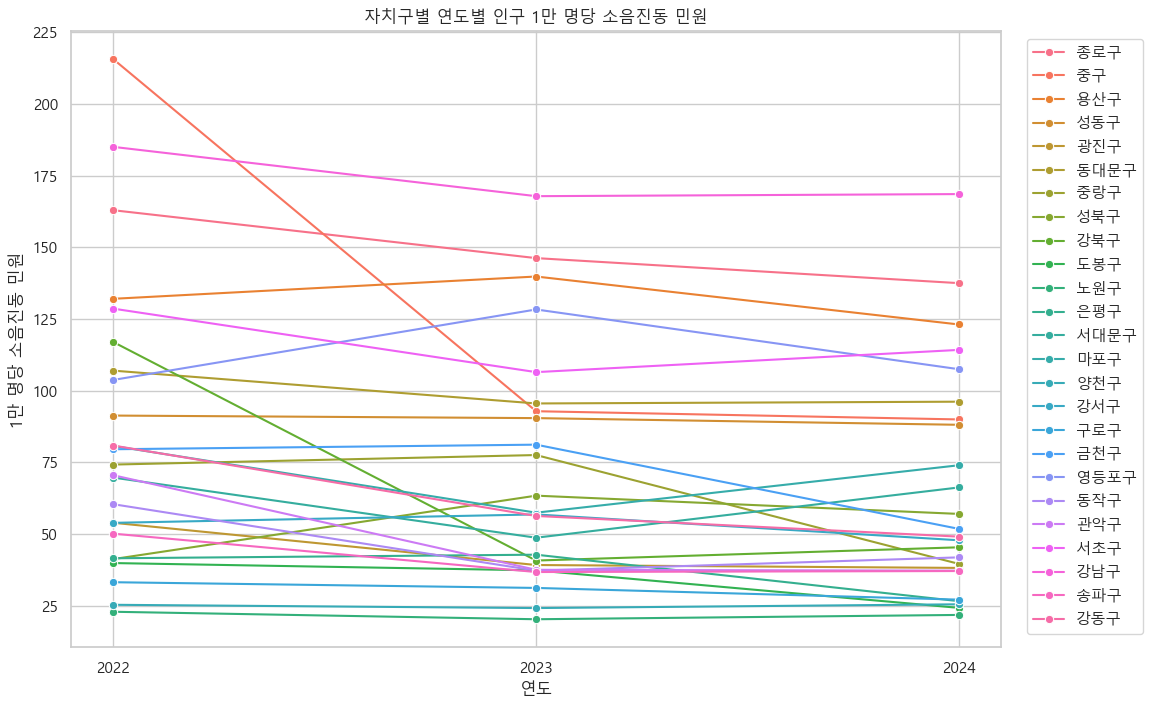

In [144]:
plt.figure(figsize=(12, 8))
sns.lineplot(
    data=trend_df,
    x="연도",
    y="만명당소음민원",
    hue="자치구",
    marker="o"
)
plt.title("자치구별 연도별 인구 1만 명당 소음진동 민원")
plt.xlabel("연도")
plt.ylabel("1만 명당 소음진동 민원")
plt.legend(bbox_to_anchor=(1.02, 1), loc="upper left")
plt.show()


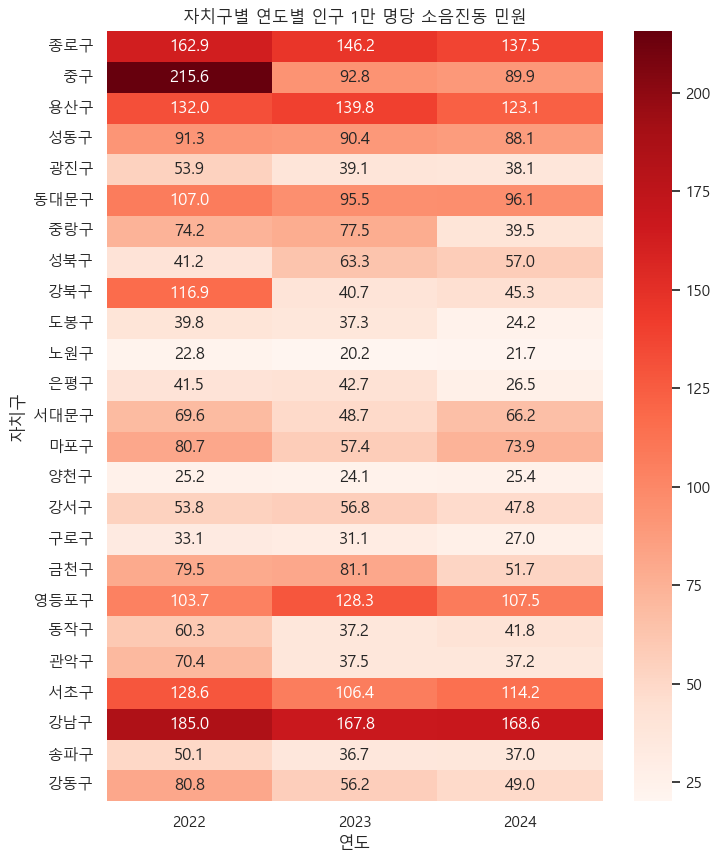

In [145]:
heatmap_df = complaint_pop.set_index("자치구")[
    ["만명당소음민원_2022", "만명당소음민원_2023", "만명당소음민원_2024"]
]
heatmap_df.columns = ["2022", "2023", "2024"]


plt.figure(figsize=(8, 10))
sns.heatmap(
    heatmap_df,
    annot=True,
    fmt=".1f",
    cmap="Reds"
)
plt.title("자치구별 연도별 인구 1만 명당 소음진동 민원")
plt.xlabel("연도")
plt.ylabel("자치구")
plt.show()

C:\Users\yiho1\AppData\Local\Temp\ipykernel_30380\3186449225.py:8: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  ax = sns.barplot(


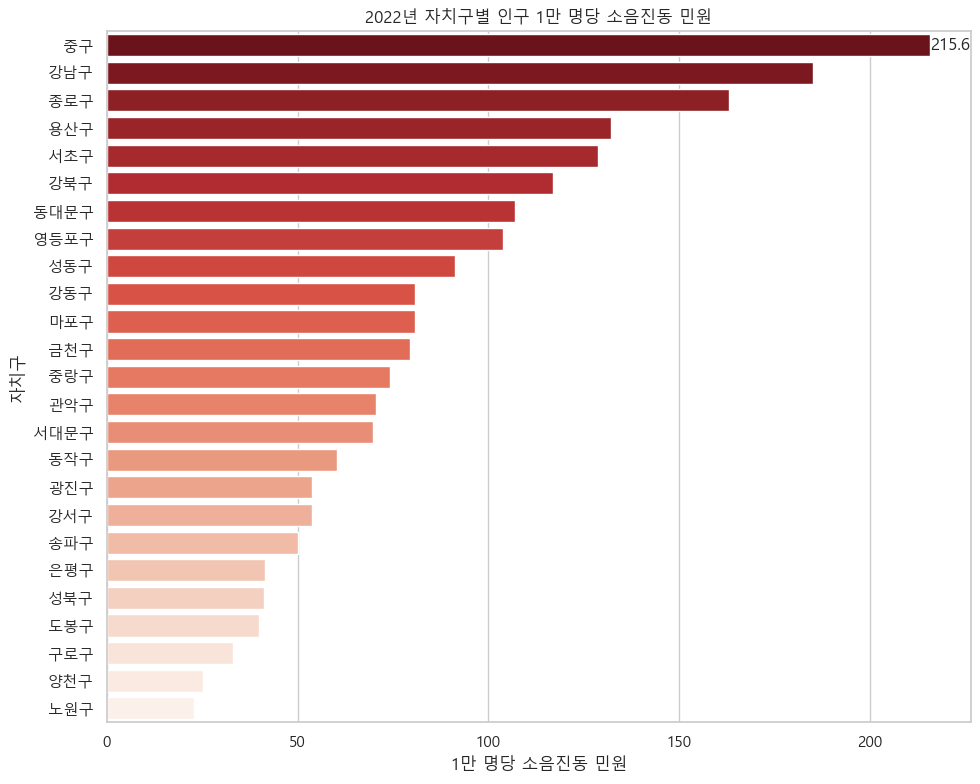

C:\Users\yiho1\AppData\Local\Temp\ipykernel_30380\3186449225.py:8: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  ax = sns.barplot(


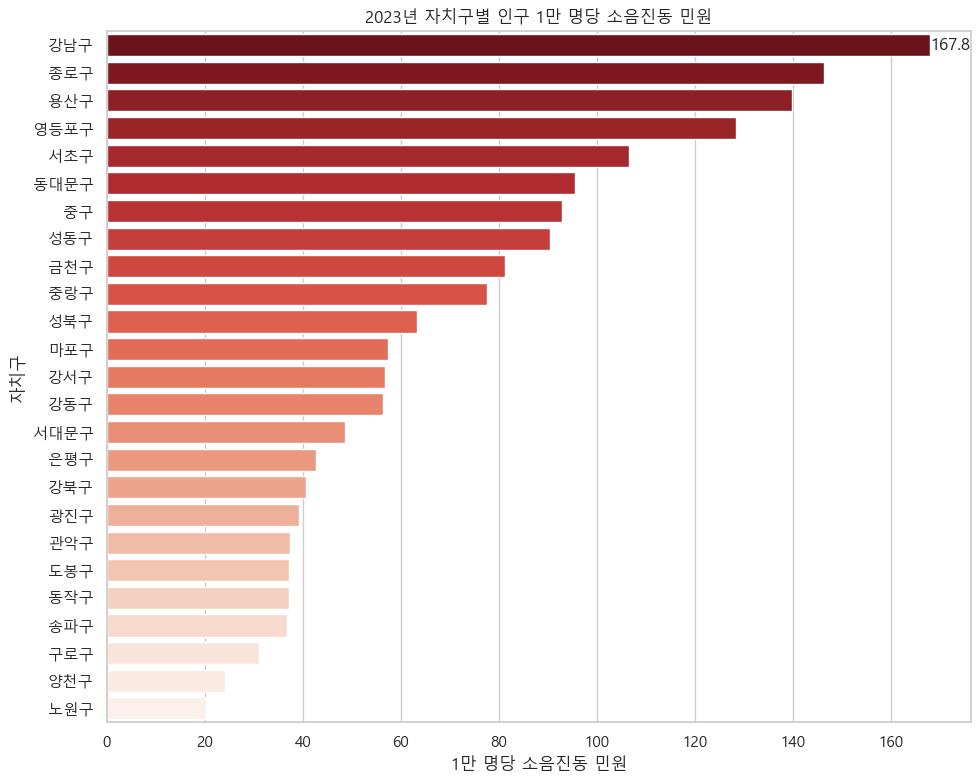

C:\Users\yiho1\AppData\Local\Temp\ipykernel_30380\3186449225.py:8: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  ax = sns.barplot(


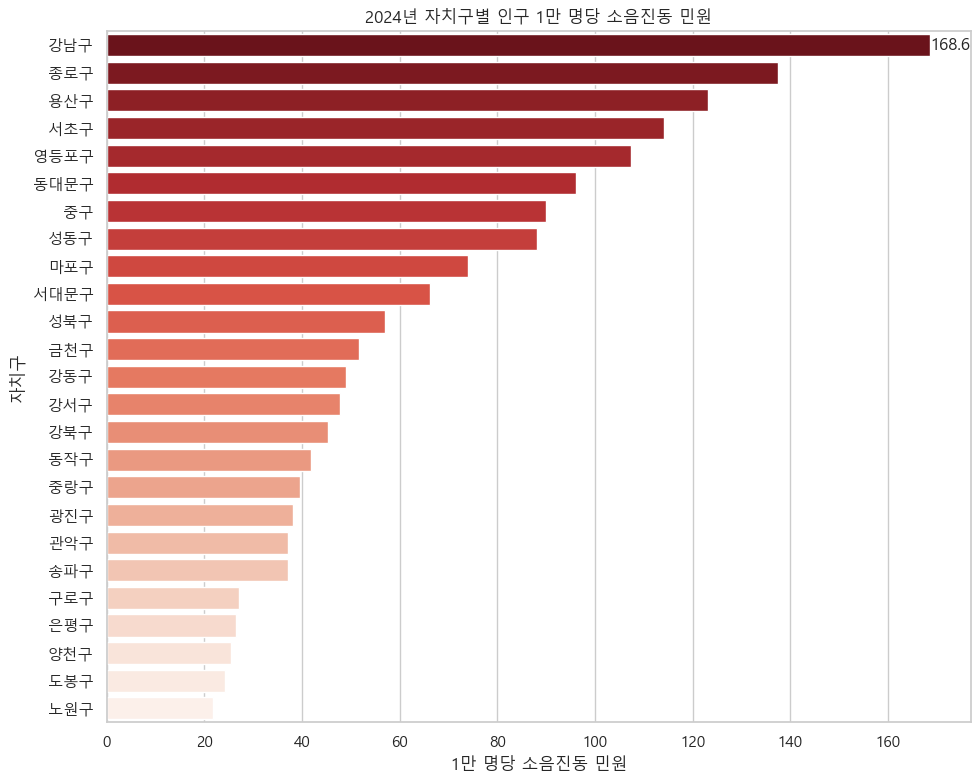

In [146]:
years = [2022, 2023, 2024]

for year in years:
    col = f"만명당소음민원_{year}"
    plot_df = complaint_pop.sort_values(col, ascending=False)

    plt.figure(figsize=(10, 8))
    ax = sns.barplot(
        data=plot_df,
        x=col,
        y="자치구",
        palette="Reds_r"
    )
    ax.bar_label(ax.containers[0], fmt="%.1f")
    plt.title(f"{year}년 자치구별 인구 1만 명당 소음진동 민원")
    plt.xlabel("1만 명당 소음진동 민원")
    plt.ylabel("자치구")
    plt.tight_layout()
    plt.show()

In [ ]:
# 스트레스가 전혀 없는 것처럼 보이는 0점을 피하기 위해 1~8점 범위로 환산
# 값이 클수록 스트레스가 높음
def to_1_8_stress_score(s):
    s = pd.to_numeric(s, errors="coerce")
    mn = s.min()
    mx = s.max()
    if mx == mn:
        return pd.Series(4.5, index=s.index)
    return 1 + (s - mn) / (mx - mn) * 7

In [148]:
complaint_pop["민원스트레스점수_2022"] = to_1_8_stress_score(complaint_pop["만명당소음민원_2022"]).round(2)
complaint_pop["민원스트레스점수_2023"] = to_1_8_stress_score(complaint_pop["만명당소음민원_2023"]).round(2)
complaint_pop["민원스트레스점수_2024"] = to_1_8_stress_score(complaint_pop["만명당소음민원_2024"]).round(2)


In [149]:
complaint_pop[[
    "자치구",
    "만명당소음민원_2022", "민원스트레스점수_2022",
    "만명당소음민원_2023", "민원스트레스점수_2023",
    "만명당소음민원_2024", "민원스트레스점수_2024"
]].head()


,자치구,만명당소음민원_2022,민원스트레스점수_2022,만명당소음민원_2023,민원스트레스점수_2023,만명당소음민원_2024,민원스트레스점수_2024
0,종로구,162.931720,6.09,146.225067,6.98,137.492647,6.52
1,중구,215.621057,8.00,92.797038,4.44,89.929428,4.25
2,용산구,132.027914,4.97,139.802559,6.67,123.069698,5.83
3,성동구,91.280002,3.49,90.390004,4.33,88.058900,4.16
4,광진구,53.864462,2.13,39.125235,1.90,38.118238,1.78


In [150]:
import pandas as pd
import plotly.express as px

seoul_coords = {
    "종로구": (37.573520, 126.978834),
    "중구": (37.563843, 126.997602),
    "용산구": (37.532527, 126.990490),
    "성동구": (37.563341, 127.036289),
    "광진구": (37.538617, 127.082375),
    "동대문구": (37.574368, 127.039593),
    "중랑구": (37.606324, 127.092584),
    "성북구": (37.589400, 127.016749),
    "강북구": (37.639610, 127.025657),
    "도봉구": (37.668768, 127.047163),
    "노원구": (37.654191, 127.056793),
    "은평구": (37.617612, 126.922700),
    "서대문구": (37.579115, 126.936778),
    "마포구": (37.566324, 126.901491),
    "양천구": (37.516873, 126.866399),
    "강서구": (37.550979, 126.849538),
    "구로구": (37.495485, 126.887445),
    "금천구": (37.456864, 126.895510),
    "영등포구": (37.526371, 126.896229),
    "동작구": (37.512402, 126.939252),
    "관악구": (37.478406, 126.951613),
    "서초구": (37.483712, 127.032411),
    "강남구": (37.517305, 127.047502),
    "송파구": (37.514575, 127.105399),
    "강동구": (37.530126, 127.123770),
}


In [151]:
coord_df = pd.DataFrame([
    {"자치구": gu, "lat": lat, "lon": lon}
    for gu, (lat, lon) in seoul_coords.items()
])

map_df = complaint_pop.merge(coord_df, on="자치구", how="left")
map_df


,자치구,소음진동민원_2022,소음진동민원_2023,소음진동민원_2024,인구_2022,인구_2023,인구_2024,만명당소음민원_2022,만명당소음민원_2023,만명당소음민원_2024,만명당소음민원_평균,증감_22_23,증감_23_24,증감률_22_23,증감률_23_24,민원스트레스점수_2022,민원스트레스점수_2023,민원스트레스점수_2024,lat,lon
0,종로구,2480,2200,2057,152211,150453,149608,162.931720,146.225067,137.492647,148.883145,-16.706653,-8.732420,-10.253776,-5.971903,6.09,6.98,6.52,37.573520,126.978834
1,중구,2820,1223,1180,130785,131793,131214,215.621057,92.797038,89.929428,132.782508,-122.824020,-2.867610,-56.962906,-3.090195,8.00,4.44,4.25,37.563843,126.997602
2,용산구,3080,3175,2673,233284,227106,217194,132.027914,139.802559,123.069698,131.633391,7.774645,-16.732861,5.888637,-11.968923,4.97,6.67,5.83,37.532527,126.990490
3,성동구,2631,2574,2477,288234,284766,281289,91.280002,90.390004,88.058900,89.909635,-0.889997,-2.331104,-0.975019,-2.578940,3.49,4.33,4.16,37.563341,127.036289
4,광진구,1892,1374,1329,351252,351180,348652,53.864462,39.125235,38.118238,43.702645,-14.739227,-1.006997,-27.363546,-2.573778,2.13,1.90,1.78,37.538617,127.082375
5,동대문구,3782,3437,3447,353601,359873,358603,106.956711,95.505915,96.123011,99.528545,-11.450797,0.617096,-10.706010,0.646134,4.05,4.57,4.55,37.574368,127.039593
6,중랑구,2894,3003,1523,390140,387470,385349,74.178500,77.502774,39.522615,63.734630,3.324274,-37.980160,4.481453,-49.004904,2.86,3.72,1.85,37.606324,127.092584
7,성북구,1821,2775,2478,441984,438168,435037,41.200586,63.331873,56.960672,53.831044,22.131286,-6.371200,53.715950,-10.060022,1.67,3.04,2.68,37.589400,127.016749
8,강북구,3481,1192,1311,297702,292977,289374,116.929010,40.685788,45.304692,67.639830,-76.243222,4.618905,-65.204710,11.352624,4.42,1.97,2.12,37.639610,127.025657
9,도봉구,1250,1153,740,313989,309494,306032,39.810312,37.254357,24.180478,33.748382,-2.555955,-13.073879,-6.420333,-35.093558,1.62,1.81,1.12,37.668768,127.047163


In [152]:
len(map_df)

25

In [153]:
for year in [2022, 2023, 2024]:
    fig = px.scatter_mapbox(
        map_df,
        lat="lat",
        lon="lon",
        size=f"민원스트레스점수_{year}",
        color=f"민원스트레스점수_{year}",
        hover_name="자치구",
        hover_data={
            "lat": False,
            "lon": False,
            f"만명당소음민원_{year}": ":.2f",
            f"민원스트레스점수_{year}": ":.2f",
        },
        color_continuous_scale="Reds",
        range_color=(0, 8),
        size_max=30,
        zoom=10,
        center={"lat": 37.55, "lon": 126.98},
        title=f"{year} 자치구별 민원 스트레스 점수"
    )
    fig.update_layout(mapbox_style="carto-positron")
    fig.show()



C:\Users\yiho1\AppData\Local\Temp\ipykernel_30380\823371400.py:2: DeprecationWarning: *scatter_mapbox* is deprecated! Use *scatter_map* instead. Learn more at: https://plotly.com/python/mapbox-to-maplibre/
  fig = px.scatter_mapbox(


C:\Users\yiho1\AppData\Local\Temp\ipykernel_30380\823371400.py:2: DeprecationWarning: *scatter_mapbox* is deprecated! Use *scatter_map* instead. Learn more at: https://plotly.com/python/mapbox-to-maplibre/
  fig = px.scatter_mapbox(


C:\Users\yiho1\AppData\Local\Temp\ipykernel_30380\823371400.py:2: DeprecationWarning: *scatter_mapbox* is deprecated! Use *scatter_map* instead. Learn more at: https://plotly.com/python/mapbox-to-maplibre/
  fig = px.scatter_mapbox(


## 소음점수

- `noise` 데이터는 자치구-지역별 월별 소음값을 wide 형태로 가지고 있습니다.
- 분석을 쉽게 하기 위해 long 형태로 바꾸고, 연도와 월을 분리합니다.
- 자치구별 평균소음, 최고소음, 소음편차를 묶어 연도별 소음 스트레스 점수를 계산합니다.

In [154]:
noise.head()

,gu_code,자치구,지역,2201,2202,2203,2204,2205,2206,2207,...,2403,2404,2405,2406,2407,2408,2409,2410,2411,2412
0,11110,종로구,main_street,49.931213,50.590938,50.130740,50.804956,50.191871,50.087831,50.443271,...,49.307064,48.380290,48.914960,48.538910,50.054460,50.515551,48.821852,48.176839,48.377358,49.302819
1,11110,종로구,public_facilities,43.971979,44.022604,43.003913,41.813812,42.290155,44.858310,46.292023,...,NaN,47.050820,47.609130,46.874636,43.589744,48.293388,44.669930,44.621438,45.353436,45.655120
2,11110,종로구,residential_area,45.520378,45.725953,44.843993,44.057325,44.136669,45.276522,45.733778,...,47.200909,46.136474,44.932364,44.327932,46.151358,47.243382,46.140823,45.427398,45.610119,45.992169
3,11110,종로구,roads_and_parks,59.954187,60.463100,60.179632,60.267141,60.732937,61.859122,60.838969,...,61.310135,61.009239,61.184323,61.430839,61.114387,61.171555,59.274934,57.637162,57.220747,57.967718
4,11140,중구,commercial_area,50.209353,50.458342,49.859668,49.117785,49.086536,49.749223,49.640019,...,49.807018,49.536946,49.513889,49.221207,49.559380,48.902965,48.749304,48.881081,48.887500,48.959641


In [ ]:

noise_long = noise.melt(
    id_vars=["gu_code", "자치구", "지역"],
    var_name="연월",
    value_name="소음값"
)

noise_long["소음값"] = pd.to_numeric(noise_long["소음값"], errors="coerce")
noise_long["연도"] = "20" + noise_long["연월"].str[:2]
noise_long["월"] = noise_long["연월"].str[2:4].astype(int)

noise_long.head()

,gu_code,자치구,지역,연월,소음값,연도,월
0,11110,종로구,main_street,2201,49.931213,2022,1
1,11110,종로구,public_facilities,2201,43.971979,2022,1
2,11110,종로구,residential_area,2201,45.520378,2022,1
3,11110,종로구,roads_and_parks,2201,59.954187,2022,1
4,11140,중구,commercial_area,2201,50.209353,2022,1


In [156]:
noise_long.groupby("자치구")["지역"].nunique().sort_values(ascending=False)

자치구
강동구     7
강남구     6
강서구     6
관악구     6
양천구     6
서초구     6
성동구     6
마포구     6
도봉구     6
송파구     6
노원구     5
구로구     5
광진구     5
강북구     5
금천구     5
서대문구    5
동작구     5
중랑구     5
은평구     5
중구      5
성북구     4
용산구     4
영등포구    4
종로구     4
동대문구    3
Name: 지역, dtype: int64

In [157]:
noise_long["연도"].value_counts()

연도
2022    1560
2023    1560
2024    1560
Name: count, dtype: int64

In [ ]:

gu_year_noise_mean = noise_long.groupby(["자치구", "연도"], as_index=False)["소음값"].mean()
gu_year_noise_mean = gu_year_noise_mean.rename(columns={"소음값": "평균소음"})
gu_year_noise_mean

,자치구,연도,평균소음
0,강남구,2022,54.317114
1,강남구,2023,56.250671
2,강남구,2024,53.903818
3,강동구,2022,54.015586
4,강동구,2023,57.137789
...,...,...,...
70,중구,2023,51.027512
71,중구,2024,48.987179
72,중랑구,2022,46.522181
73,중랑구,2023,48.255502


In [159]:
gu_year_noise_max = noise_long.groupby(["자치구", "연도"], as_index=False)["소음값"].max()
gu_year_noise_max = gu_year_noise_max.rename(columns={"소음값": "최고소음"})
gu_year_noise_max

,자치구,연도,최고소음
0,강남구,2022,66.458626
1,강남구,2023,149.035011
2,강남구,2024,64.710982
3,강동구,2022,66.331813
4,강동구,2023,336.269203
...,...,...,...
70,중구,2023,114.721714
71,중구,2024,57.389445
72,중랑구,2022,59.898828
73,중랑구,2023,66.936956


In [160]:
gu_year_noise_std = noise_long.groupby(["자치구", "연도"], as_index=False)["소음값"].std()
gu_year_noise_std = gu_year_noise_std.rename(columns={"소음값": "소음편차"})
gu_year_noise_std

,자치구,연도,소음편차
0,강남구,2022,5.958681
1,강남구,2023,13.134868
2,강남구,2024,7.221929
3,강동구,2022,7.094437
4,강동구,2023,33.155333
...,...,...,...
70,중구,2023,9.275005
71,중구,2024,3.865546
72,중랑구,2022,6.188444
73,중랑구,2023,6.112194


In [161]:
noise_summary = gu_year_noise_mean.merge(
    gu_year_noise_max,
    on=["자치구", "연도"],
    how="left"
).merge(
    gu_year_noise_std,
    on=["자치구", "연도"],
    how="left"
)

noise_summary.head()

,자치구,연도,평균소음,최고소음,소음편차
0,강남구,2022,54.317114,66.458626,5.958681
1,강남구,2023,56.250671,149.035011,13.134868
2,강남구,2024,53.903818,64.710982,7.221929
3,강동구,2022,54.015586,66.331813,7.094437
4,강동구,2023,57.137789,336.269203,33.155333


In [162]:
def zscore(s):
    s = pd.to_numeric(s, errors="coerce")
    std = s.std()
    if std == 0 or pd.isna(std):
        return pd.Series(0, index=s.index)
    return (s - s.mean()) / std

In [ ]:

noise_summary["소음대표지표"] = (
    0.6 * zscore(noise_summary["평균소음"]) +
    0.3 * zscore(noise_summary["최고소음"]) +
    0.1 * zscore(noise_summary["소음편차"].fillna(0))
)

noise_summary.head()


,자치구,연도,평균소음,최고소음,소음편차,소음대표지표
0,강남구,2022,54.317114,66.458626,5.958681,0.302346
1,강남구,2023,56.250671,149.035011,13.134868,1.094078
2,강남구,2024,53.903818,64.710982,7.221929,0.228538
3,강동구,2022,54.015586,66.331813,7.094437,0.255528
4,강동구,2023,57.137789,336.269203,33.155333,2.243607


In [164]:
def to_1_8_stress_score(s):
    s = pd.to_numeric(s, errors="coerce")
    mn = s.min()
    mx = s.max()
    if mx == mn:
        return pd.Series(4.5, index=s.index)
    return 1 + (s - mn) / (mx - mn) * 7

In [165]:
noise_summary["소음스트레스점수"] = noise_summary.groupby("연도")["소음대표지표"].transform(
    lambda x: to_1_8_stress_score(x)
).round(2)

noise_summary.head()

,자치구,연도,평균소음,최고소음,소음편차,소음대표지표,소음스트레스점수
0,강남구,2022,54.317114,66.458626,5.958681,0.302346,5.73
1,강남구,2023,56.250671,149.035011,13.134868,1.094078,3.90
2,강남구,2024,53.903818,64.710982,7.221929,0.228538,5.80
3,강동구,2022,54.015586,66.331813,7.094437,0.255528,5.58
4,강동구,2023,57.137789,336.269203,33.155333,2.243607,5.58


In [166]:
noise_summary["소음스트레스점수"] = noise_summary.groupby("연도")["소음대표지표"].transform(
    lambda x: to_1_8_stress_score(x)
).round(2)

noise_summary

,자치구,연도,평균소음,최고소음,소음편차,소음대표지표,소음스트레스점수
0,강남구,2022,54.317114,66.458626,5.958681,0.302346,5.73
1,강남구,2023,56.250671,149.035011,13.134868,1.094078,3.90
2,강남구,2024,53.903818,64.710982,7.221929,0.228538,5.80
3,강동구,2022,54.015586,66.331813,7.094437,0.255528,5.58
4,강동구,2023,57.137789,336.269203,33.155333,2.243607,5.58
...,...,...,...,...,...,...,...
70,중구,2023,51.027512,114.721714,9.275005,-0.115591,2.13
71,중구,2024,48.987179,57.389445,3.865546,-0.807668,2.34
72,중랑구,2022,46.522181,59.898828,6.188444,-1.256484,1.00
73,중랑구,2023,48.255502,66.936956,6.112194,-0.887967,1.00


In [167]:
noise_score_wide = noise_summary.pivot(
    index="자치구",
    columns="연도",
    values="소음스트레스점수"
).reset_index()

noise_score_wide.columns = ["자치구", "소음스트레스점수_2022", "소음스트레스점수_2023", "소음스트레스점수_2024"]

noise_score_wide.head()

,자치구,소음스트레스점수_2022,소음스트레스점수_2023,소음스트레스점수_2024
0,강남구,5.73,3.90,5.80
1,강동구,5.58,5.58,4.67
2,강북구,3.02,2.78,3.01
3,강서구,7.40,3.53,6.30
4,관악구,3.28,1.50,2.98


C:\Users\yiho1\AppData\Local\Temp\ipykernel_30380\4001496659.py:8: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  ax = sns.barplot(


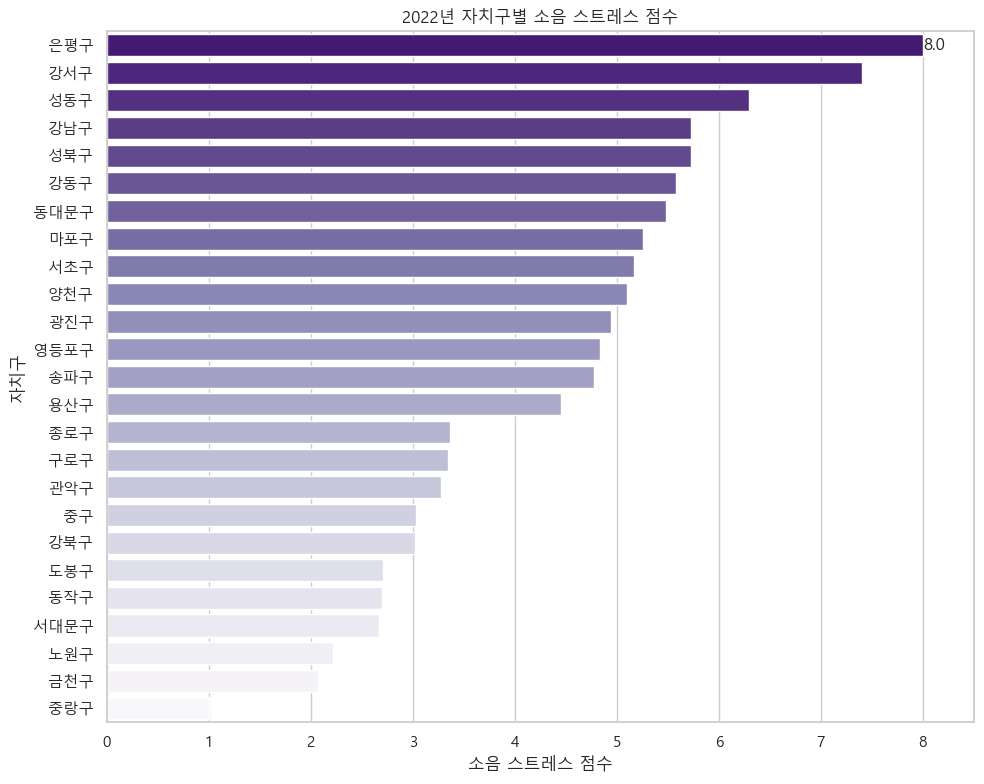

C:\Users\yiho1\AppData\Local\Temp\ipykernel_30380\4001496659.py:8: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  ax = sns.barplot(


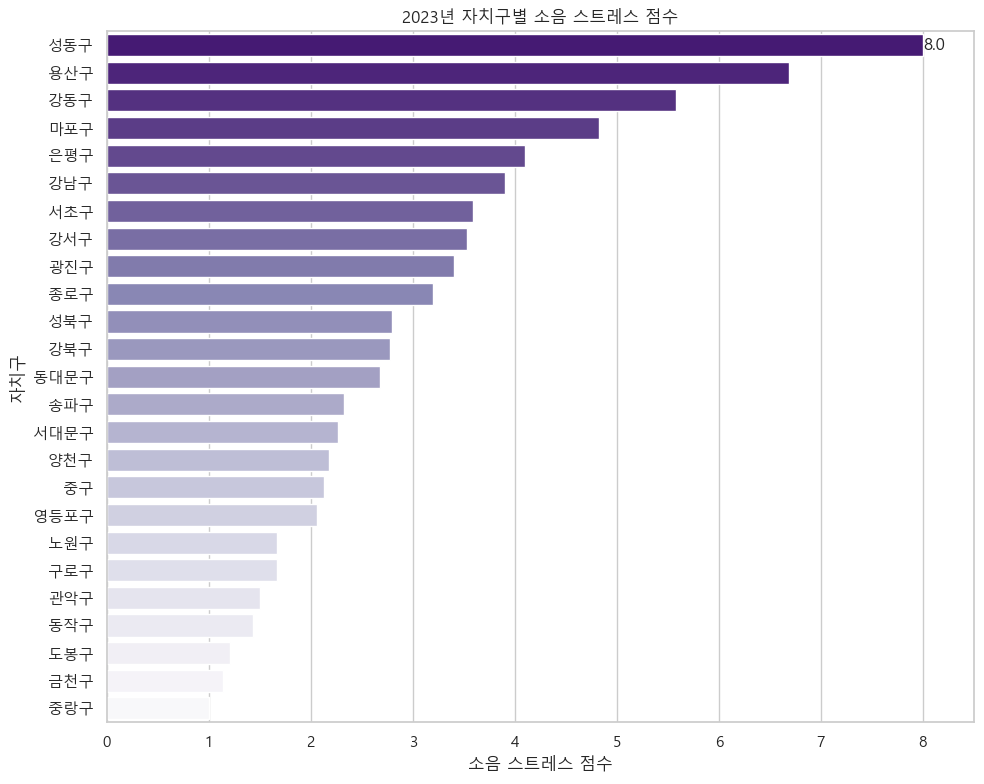

C:\Users\yiho1\AppData\Local\Temp\ipykernel_30380\4001496659.py:8: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  ax = sns.barplot(


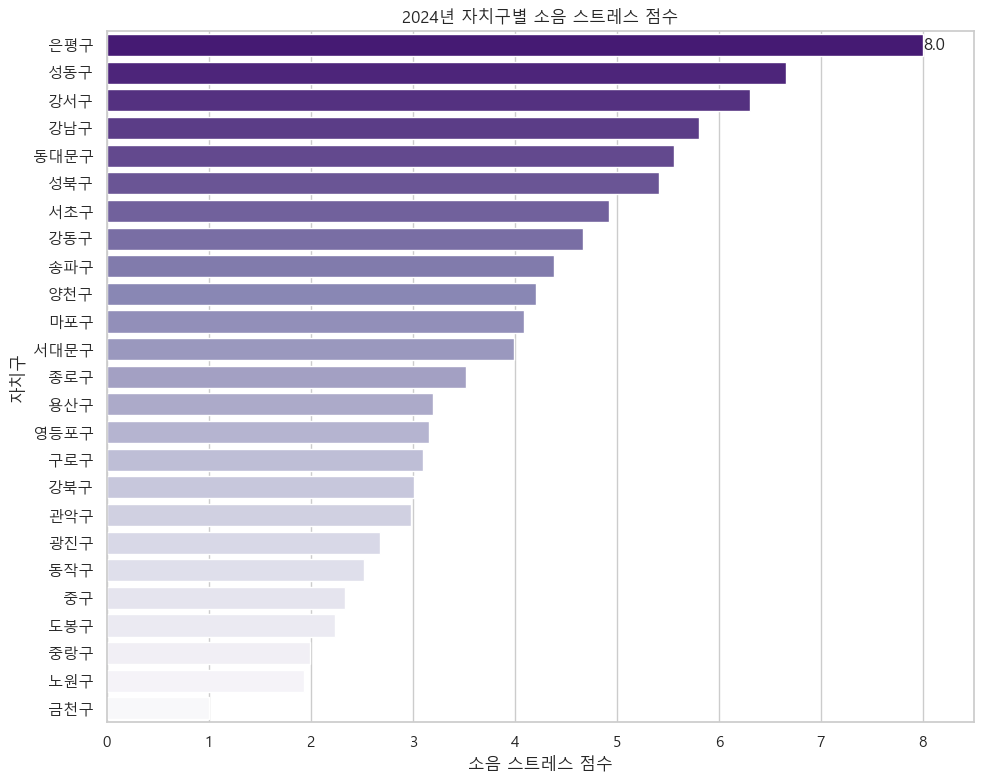

In [168]:
years = [2022, 2023, 2024]

for year in years:
    col = f"소음스트레스점수_{year}"
    plot_df = noise_score_wide.sort_values(col, ascending=False)

    plt.figure(figsize=(10, 8))
    ax = sns.barplot(
        data=plot_df,
        x=col,
        y="자치구",
        palette="Purples_r"
    )
    ax.bar_label(ax.containers[0], fmt="%.1f")
    plt.title(f"{year}년 자치구별 소음 스트레스 점수")
    plt.xlabel("소음 스트레스 점수")
    plt.ylabel("자치구")
    plt.xlim(0, 8.5)
    plt.tight_layout()
    plt.show()


C:\Users\yiho1\AppData\Local\Temp\ipykernel_30380\3064459148.py:7: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  ax = sns.barplot(


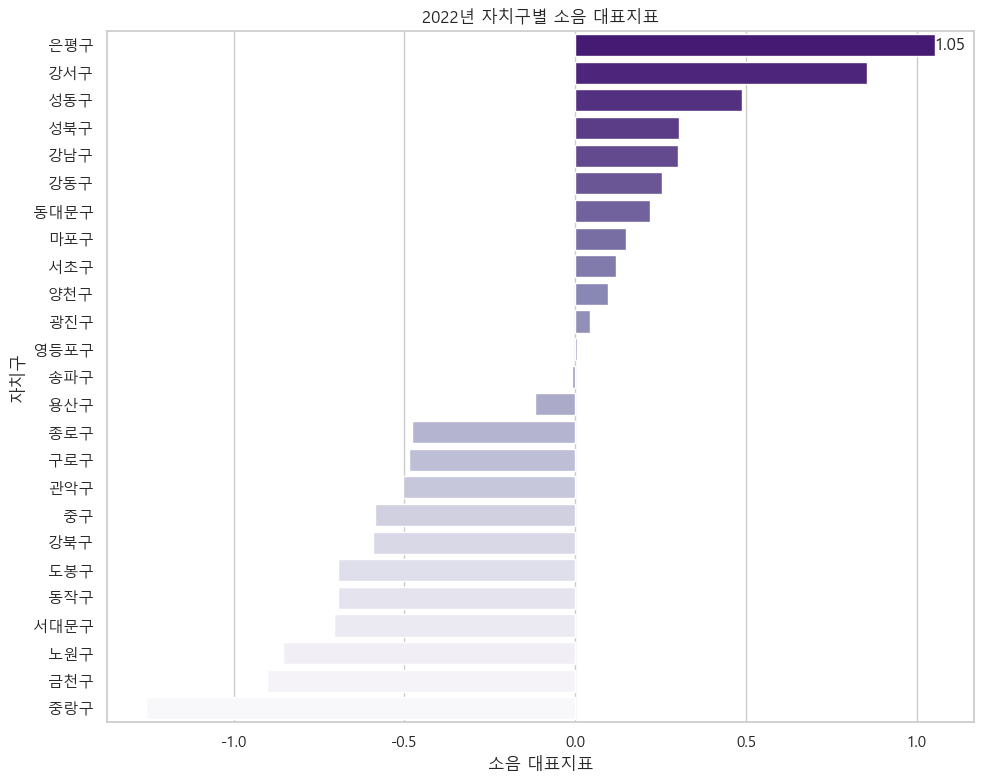

C:\Users\yiho1\AppData\Local\Temp\ipykernel_30380\3064459148.py:7: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  ax = sns.barplot(


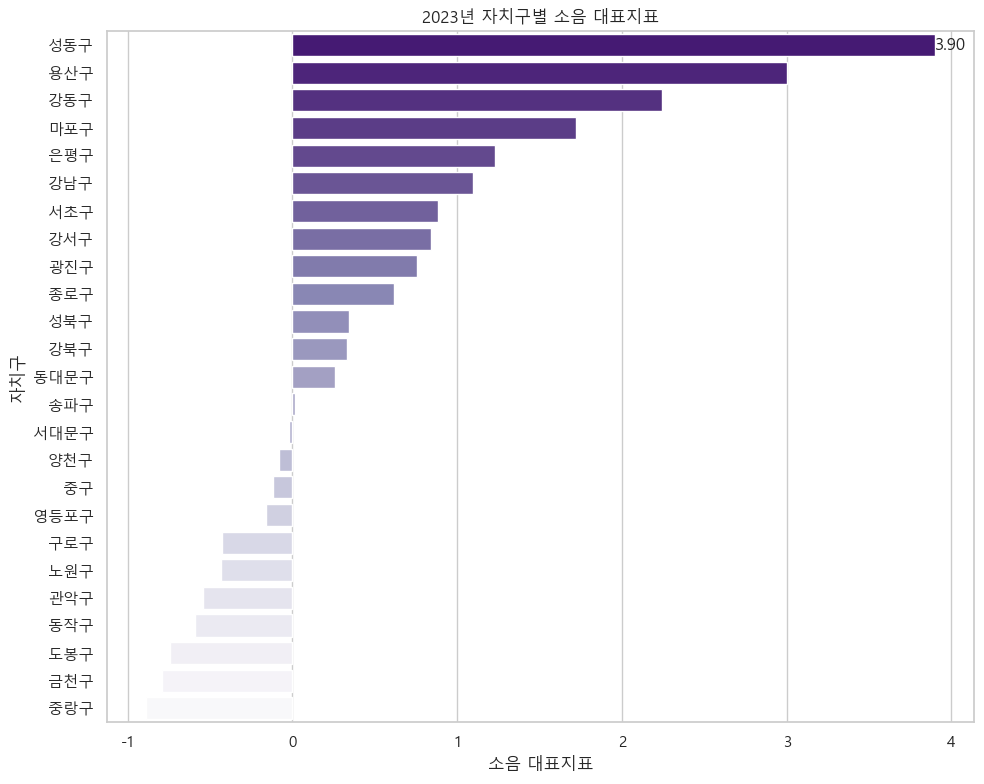

C:\Users\yiho1\AppData\Local\Temp\ipykernel_30380\3064459148.py:7: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  ax = sns.barplot(


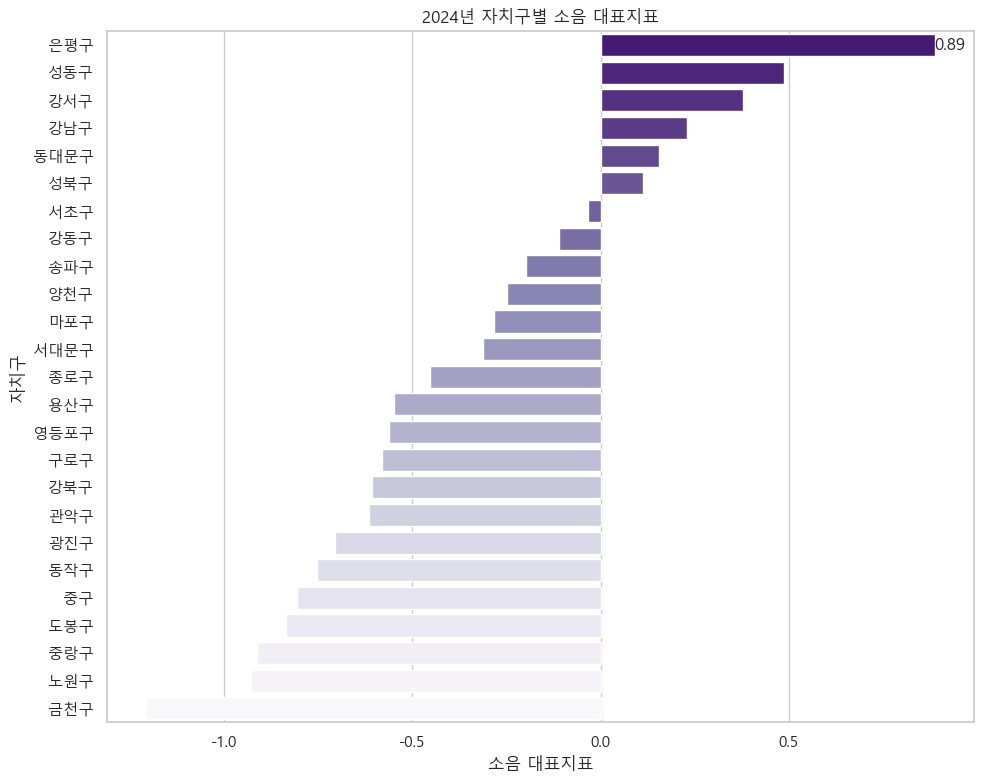

In [169]:
years = ["2022", "2023", "2024"]

for year in years:
    plot_df = noise_summary[noise_summary["연도"] == year].sort_values("소음대표지표", ascending=False)

    plt.figure(figsize=(10, 8))
    ax = sns.barplot(
        data=plot_df,
        x="소음대표지표",
        y="자치구",
        palette="Purples_r"
    )
    ax.bar_label(ax.containers[0], fmt="%.2f")
    plt.title(f"{year}년 자치구별 소음 대표지표")
    plt.xlabel("소음 대표지표")
    plt.ylabel("자치구")
    plt.tight_layout()
    plt.show()


## 진동점수

In [ ]:

vibration_long = vibration.melt(
    id_vars=["gu_code", "자치구"],
    var_name="연월축",
    value_name="진동값"
)

vibration_long["진동값"] = pd.to_numeric(vibration_long["진동값"], errors="coerce")
vibration_long["연도"] = "20" + vibration_long["연월축"].str[:2]
vibration_long["월"] = vibration_long["연월축"].str[2:4].astype(int)
vibration_long["축"] = vibration_long["연월축"].str[-1]

vibration_long.head()

,gu_code,자치구,연월축,진동값,연도,월,축
0,11110,종로구,2201_v_x,0.031804,2022,1,x
1,11140,중구,2201_v_x,0.023529,2022,1,x
2,11170,용산구,2201_v_x,0.025965,2022,1,x
3,11200,성동구,2201_v_x,0.025986,2022,1,x
4,11215,광진구,2201_v_x,0.029504,2022,1,x


In [ ]:

vibration_axis_summary = vibration_long.groupby(["자치구", "연도", "축"], as_index=False)["진동값"].mean()
vibration_axis_summary = vibration_axis_summary.rename(columns={"진동값": "평균진동"})
vibration_axis_summary

,자치구,연도,축,평균진동
0,강남구,2022,x,0.117936
1,강남구,2022,y,0.257602
2,강남구,2022,z,3.904527
3,강남구,2023,x,0.048231
4,강남구,2023,y,0.095787
...,...,...,...,...
220,중랑구,2023,y,0.097326
221,중랑구,2023,z,1.509135
222,중랑구,2024,x,0.033088
223,중랑구,2024,y,0.071040


In [172]:
vibration_axis_summary["축별진동스트레스점수"] = vibration_axis_summary.groupby(["연도", "축"])["평균진동"].transform(
    lambda x: to_1_8_stress_score(x)
).round(2)
vibration_axis_summary

,자치구,연도,축,평균진동,축별진동스트레스점수
0,강남구,2022,x,0.117936,5.97
1,강남구,2022,y,0.257602,7.35
2,강남구,2022,z,3.904527,4.15
3,강남구,2023,x,0.048231,6.68
4,강남구,2023,y,0.095787,6.02
...,...,...,...,...,...
220,중랑구,2023,y,0.097326,6.38
221,중랑구,2023,z,1.509135,6.60
222,중랑구,2024,x,0.033088,7.39
223,중랑구,2024,y,0.071040,7.93


In [173]:
vibration_axis_wide = vibration_axis_summary.pivot(
    index=["자치구", "연도"],
    columns="축",
    values="축별진동스트레스점수"
).reset_index()

vibration_axis_wide.columns = ["자치구", "연도", "진동X점수", "진동Y점수", "진동Z점수"]
vibration_axis_wide

,자치구,연도,진동X점수,진동Y점수,진동Z점수
0,강남구,2022,5.97,7.35,4.15
1,강남구,2023,6.68,6.02,5.85
2,강남구,2024,4.89,4.32,5.58
3,강동구,2022,4.00,3.41,1.21
4,강동구,2023,3.81,2.55,2.76
...,...,...,...,...,...
70,중구,2023,1.98,5.91,1.00
71,중구,2024,2.89,7.93,2.29
72,중랑구,2022,4.79,5.78,4.17
73,중랑구,2023,5.60,6.38,6.60


In [ ]:

vibration_axis_wide["진동스트레스점수"] = vibration_axis_wide[
    ["진동X점수", "진동Y점수", "진동Z점수"]
].mean(axis=1).round(2)

vibration_axis_wide.head()

,자치구,연도,진동X점수,진동Y점수,진동Z점수,진동스트레스점수
0,강남구,2022,5.97,7.35,4.15,5.82
1,강남구,2023,6.68,6.02,5.85,6.18
2,강남구,2024,4.89,4.32,5.58,4.93
3,강동구,2022,4.00,3.41,1.21,2.87
4,강동구,2023,3.81,2.55,2.76,3.04


In [175]:
vibration_score_wide = vibration_axis_wide.pivot(
    index="자치구",
    columns="연도",
    values="진동스트레스점수"
).reset_index()

vibration_score_wide.columns = [
    "자치구",
    "진동스트레스점수_2022",
    "진동스트레스점수_2023",
    "진동스트레스점수_2024"
]

vibration_score_wide.head()


,자치구,진동스트레스점수_2022,진동스트레스점수_2023,진동스트레스점수_2024
0,강남구,5.82,6.18,4.93
1,강동구,2.87,3.04,3.45
2,강북구,3.20,4.18,4.78
3,강서구,4.35,3.63,3.66
4,관악구,3.90,4.67,4.87


In [ ]:

final_noise = complaint_pop[[
    "자치구",
    "민원스트레스점수_2022",
    "민원스트레스점수_2023",
    "민원스트레스점수_2024"
]].merge(
    noise_score_wide,
    on="자치구",
    how="left"
).merge(
    vibration_score_wide,
    on="자치구",
    how="left"
)

final_noise.head()

,자치구,민원스트레스점수_2022,민원스트레스점수_2023,민원스트레스점수_2024,소음스트레스점수_2022,소음스트레스점수_2023,소음스트레스점수_2024,진동스트레스점수_2022,진동스트레스점수_2023,진동스트레스점수_2024
0,종로구,6.09,6.98,6.52,3.36,3.20,3.52,3.96,4.16,4.73
1,중구,8.00,4.44,4.25,3.03,2.13,2.34,2.63,2.96,4.37
2,용산구,4.97,6.67,5.83,4.45,6.69,3.20,3.34,4.02,4.14
3,성동구,3.49,4.33,4.16,6.29,8.00,6.66,3.87,4.62,5.09
4,광진구,2.13,1.90,1.78,4.94,3.40,2.68,4.25,4.73,4.82


In [177]:
final_noise.isnull().sum()

자치구              0
민원스트레스점수_2022    0
민원스트레스점수_2023    0
민원스트레스점수_2024    0
소음스트레스점수_2022    0
소음스트레스점수_2023    0
소음스트레스점수_2024    0
진동스트레스점수_2022    0
진동스트레스점수_2023    0
진동스트레스점수_2024    0
dtype: int64

In [ ]:
final_noise["소음원점수_2022"] = (
    final_noise["민원스트레스점수_2022"] +
    final_noise["소음스트레스점수_2022"] +
    final_noise["진동스트레스점수_2022"]
).round(2)

final_noise["소음원점수_2023"] = (
    final_noise["민원스트레스점수_2023"] +
    final_noise["소음스트레스점수_2023"] +
    final_noise["진동스트레스점수_2023"]
).round(2)

final_noise["소음원점수_2024"] = (
    final_noise["민원스트레스점수_2024"] +
    final_noise["소음스트레스점수_2024"] +
    final_noise["진동스트레스점수_2024"]
).round(2)

In [ ]:
final_noise["소음총점수_2022"] = (final_noise["소음원점수_2022"] * (25 / 24)).round(2)
final_noise["소음총점수_2023"] = (final_noise["소음원점수_2023"] * (25 / 24)).round(2)
final_noise["소음총점수_2024"] = (final_noise["소음원점수_2024"] * (25 / 24)).round(2)

In [180]:
final_noise[[
    "자치구",
    "민원스트레스점수_2022", "소음스트레스점수_2022", "진동스트레스점수_2022", "소음총점수_2022",
    "민원스트레스점수_2023", "소음스트레스점수_2023", "진동스트레스점수_2023", "소음총점수_2023",
    "민원스트레스점수_2024", "소음스트레스점수_2024", "진동스트레스점수_2024", "소음총점수_2024"
]].head()

,자치구,민원스트레스점수_2022,소음스트레스점수_2022,진동스트레스점수_2022,소음총점수_2022,민원스트레스점수_2023,소음스트레스점수_2023,진동스트레스점수_2023,소음총점수_2023,민원스트레스점수_2024,소음스트레스점수_2024,진동스트레스점수_2024,소음총점수_2024
0,종로구,6.09,3.36,3.96,13.97,6.98,3.20,4.16,14.94,6.52,3.52,4.73,15.39
1,중구,8.00,3.03,2.63,14.23,4.44,2.13,2.96,9.93,4.25,2.34,4.37,11.42
2,용산구,4.97,4.45,3.34,13.29,6.67,6.69,4.02,18.10,5.83,3.20,4.14,13.72
3,성동구,3.49,6.29,3.87,14.22,4.33,8.00,4.62,17.66,4.16,6.66,5.09,16.57
4,광진구,2.13,4.94,4.25,11.79,1.90,3.40,4.73,10.45,1.78,2.68,4.82,9.67


In [181]:
final_noise.sort_values("소음총점수_2022", ascending=False)[
    ["자치구", "소음총점수_2022"]
]

,자치구,소음총점수_2022
22,강남구,19.21
21,서초구,15.58
11,은평구,14.88
18,영등포구,14.50
15,강서구,14.46
5,동대문구,14.41
13,마포구,14.27
1,중구,14.23
3,성동구,14.22
0,종로구,13.97


C:\Users\yiho1\AppData\Local\Temp\ipykernel_30380\438153630.py:8: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  ax = sns.barplot(


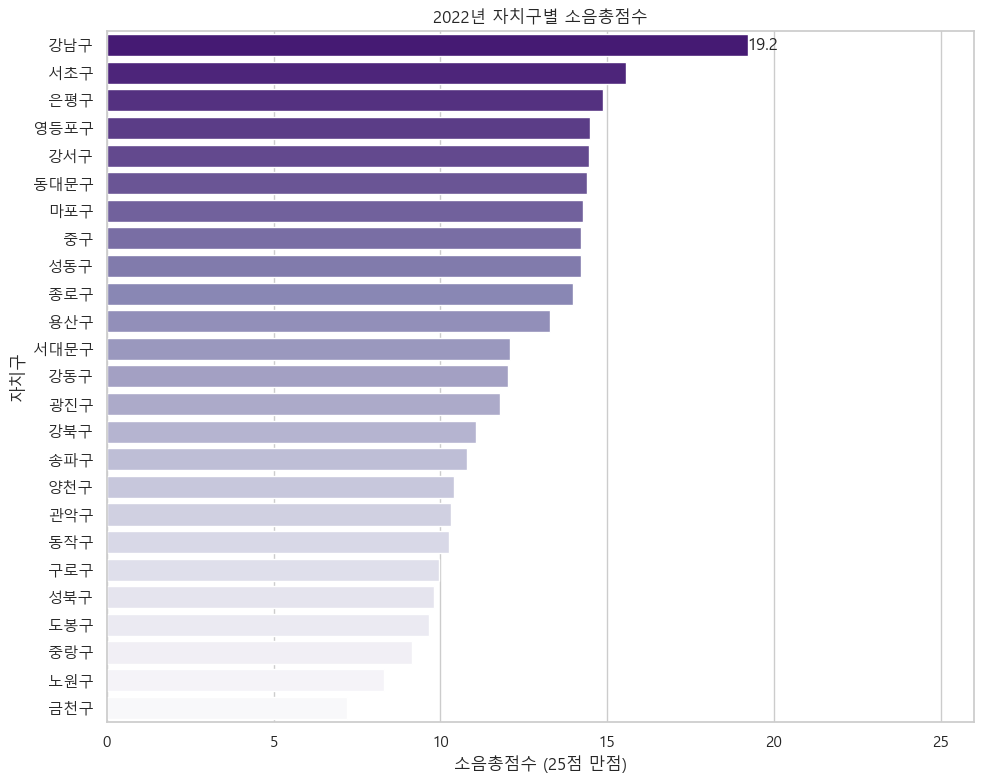

C:\Users\yiho1\AppData\Local\Temp\ipykernel_30380\438153630.py:8: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  ax = sns.barplot(


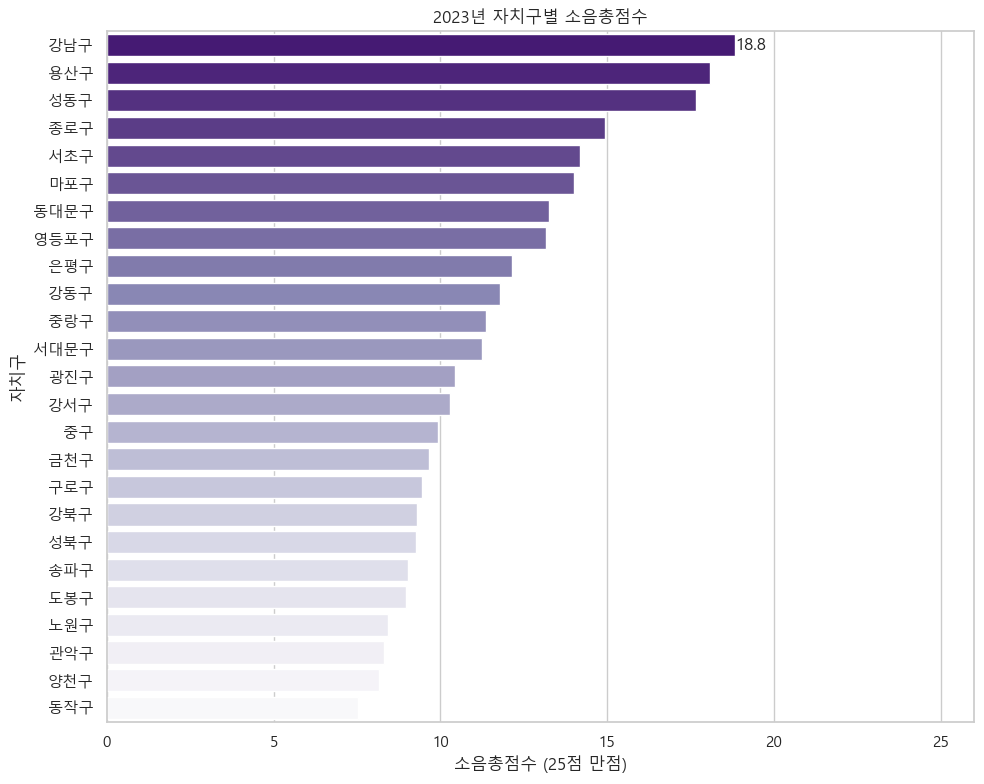

C:\Users\yiho1\AppData\Local\Temp\ipykernel_30380\438153630.py:8: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  ax = sns.barplot(


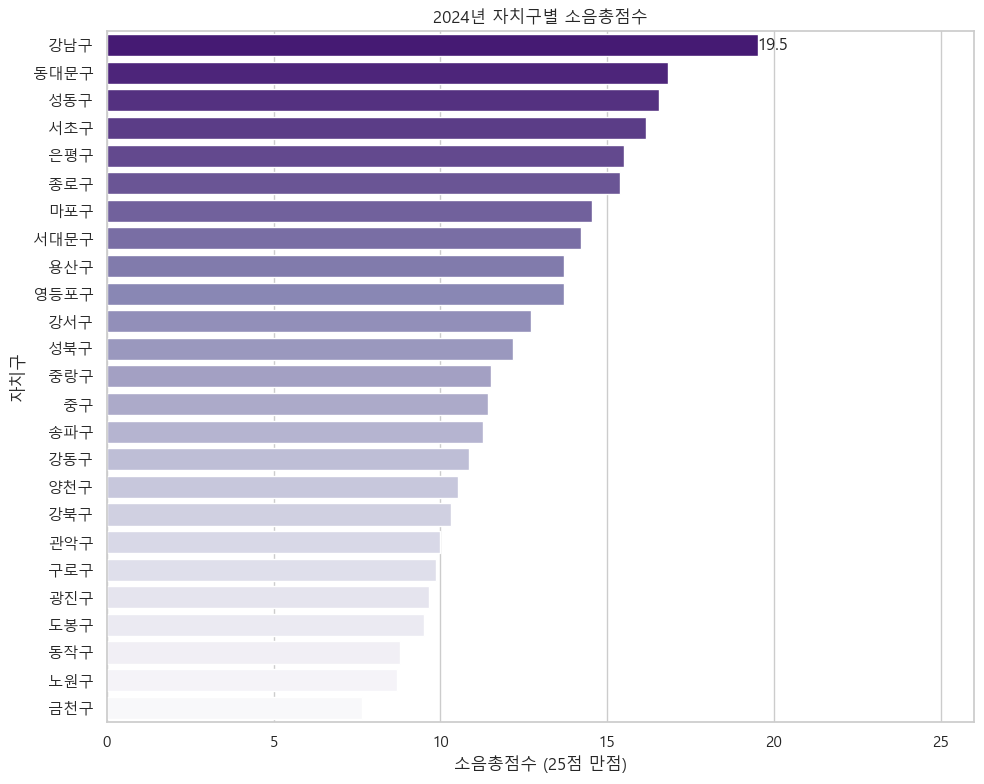

In [182]:
years = [2022, 2023, 2024]

for year in years:
    col = f"소음총점수_{year}"
    plot_df = final_noise.sort_values(col, ascending=False)

    plt.figure(figsize=(10, 8))
    ax = sns.barplot(
        data=plot_df,
        x=col,
        y="자치구",
        palette="Purples_r"
    )
    ax.bar_label(ax.containers[0], fmt="%.1f")
    plt.title(f"{year}년 자치구별 소음총점수")
    plt.xlabel("소음총점수 (25점 만점)")
    plt.ylabel("자치구")
    plt.xlim(0, 26)
    plt.tight_layout()
    plt.show()
